# Project 2 — Descriptor-Based Baseline Models

This notebook builds simple baseline models using the Article 2 clean dataset.

The goal is not to claim strong predictive performance, because the dataset is very small.  
The goal is to test whether descriptor-based features show an initial signal for explaining inhibition efficiency.

Main tasks:

1. Load Article 2 clean dataset
2. Select descriptor-based features
3. Define target variable
4. Train simple baseline regression models
5. Evaluate model performance
6. Interpret the results with scientific limitations

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict

In [2]:
current_path = Path.cwd()
if current_path.name == "notebooks":
    project_path = current_path.parent
else:
    project_path = Path("project2_descriptor")

processed_path = project_path / "data" / "processed"
reports_path = project_path / "reports"

article2_clean_file = processed_path / "article2_clean_temperature_target_v1.csv"

print("Project path:", project_path)
print("Article 2 clean file:", article2_clean_file)
print("File exists:", article2_clean_file.exists())

Project path: D:\AI\ai-corrosion-roadmap\project2_descriptor
Article 2 clean file: D:\AI\ai-corrosion-roadmap\project2_descriptor\data\processed\article2_clean_temperature_target_v1.csv
File exists: True


In [3]:
article2_data = pd.read_csv(article2_clean_file)
article2_data.head()

,source_article,molecule_id,molecule_name,compound_type,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,ionization_potential_eV,electron_affinity_eV,...,concentration_ppm,method,inhibition_efficiency_percent,corrosion_rate,icorr,Rct,performance_rank_in_paper,performance_class_raw,table_source,notes
0,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,308.0,-4.156,-2.753,1.403,4.156,2.753,...,1000,Polarization,91.0,NaN,0.09950,NaN,highest at this temperature,high,Article 2 Table 2,Target extracted from Tafel polarization data ...
1,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,308.0,-4.156,-2.753,1.403,4.156,2.753,...,1000,EIS,88.5,NaN,NaN,223.00,highest at this temperature,high,Article 2 Table 3,Target extracted from EIS data at 1000 ppm QE.
2,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,318.0,-5.486,-3.654,1.832,5.486,3.654,...,1000,Polarization,85.0,NaN,0.23300,NaN,highest at this temperature,high,Article 2 Table 2,Target extracted from Tafel polarization data ...
3,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,318.0,-5.486,-3.654,1.832,5.486,3.654,...,1000,EIS,77.9,NaN,NaN,65.59,highest at this temperature,medium-high,Article 2 Table 3,Target extracted from EIS data at 1000 ppm QE.
4,Article 2,A2_M1,4-O-CQA,quince-derived inhibitor,328.0,-4.312,-2.759,1.553,4.312,2.759,...,1000,Polarization,81.0,NaN,0.32878,NaN,highest at this temperature,high,Article 2 Table 2,Target extracted from Tafel polarization data ...


In [4]:
feature_columns = ["temperature_K","EHOMO_eV",
                   "ELUMO_eV","energy_gap_eV",
                   "hardness_eV","fraction_electron_transfer_deltaN",
                   "adsorption_energy_kcal_mol"]

target_column = "inhibition_efficiency_percent"

X = article2_data[feature_columns]
y = article2_data[target_column]

In [5]:
X

,temperature_K,EHOMO_eV,ELUMO_eV,energy_gap_eV,hardness_eV,fraction_electron_transfer_deltaN,adsorption_energy_kcal_mol
0,308.0,-4.156,-2.753,1.403,0.700,2.532,-204.962
1,308.0,-4.156,-2.753,1.403,0.700,2.532,-204.962
2,318.0,-5.486,-3.654,1.832,0.916,1.326,-222.511
3,318.0,-5.486,-3.654,1.832,0.916,1.326,-222.511
4,328.0,-4.312,-2.759,1.553,0.776,2.230,-233.004
5,328.0,-4.312,-2.759,1.553,0.776,2.230,-233.004


In [6]:
y

0    91.0
1    88.5
2    85.0
3    77.9
4    81.0
5    78.0
Name: inhibition_efficiency_percent, dtype: float64

In [7]:
linear_model = LinearRegression()
linear_model.fit(X, y)
linear_predictions = linear_model.predict(X)

print("Predictions:")
print(linear_predictions)

Predictions:
[89.75     89.75     81.421875 81.421875 79.46875  79.46875 ]


In [8]:
linear_mae = mean_absolute_error(y, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y, linear_predictions))
linear_r2 = r2_score(y, linear_predictions)

print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

MAE: 2.099999999999999
RMSE: 2.3392853309023662
R2: 0.7830383139454847


## Linear Regression: training performance

A simple Linear Regression model was trained using descriptor-based features from Article 2.

The model produced the same prediction for polarization and EIS rows at the same temperature because the experimental method was not included as an input feature.

The training performance was:

- MAE ≈ 2.10
- RMSE ≈ 2.34
- R² ≈ 0.78

These results are calculated on the same data used for training. Therefore, they should not be interpreted as real predictive performance. They only show that the model can fit the small training dataset to some extent.

In [9]:
loo = LeaveOneOut()
linear_cv_predictions = cross_val_predict(LinearRegression(),X,y,cv=loo)
linear_cv_predictions

array([88.5      , 91.       , 77.8984375, 85.       , 78.       ,
       81.03125  ])

In [10]:
linear_cv_mae = mean_absolute_error(y, linear_cv_predictions)
linear_cv_rmse = np.sqrt(mean_squared_error(y, linear_cv_predictions))
linear_cv_r2 = r2_score(y, linear_cv_predictions)

print("Linear Regression Leave-One-Out CV performance:")
print("MAE:", linear_cv_mae)
print("RMSE:", linear_cv_rmse)
print("R2:", linear_cv_r2)

Linear Regression Leave-One-Out CV performance:
MAE: 4.205468749999994
RMSE: 4.6820698147989
R2: 0.1308546266261712


## Linear Regression: Leave-One-Out cross-validation

Leave-One-Out cross-validation was used because the Article 2 dataset contains only six rows.

The cross-validation performance was weaker than the training performance:

- MAE ≈ 4.21
- RMSE ≈ 4.68
- R² ≈ 0.13

This shows that the Linear Regression model has limited predictive ability on unseen rows. The result is expected because the dataset is very small and contains repeated temperature-based descriptor values for polarization and EIS rows.

Therefore, the model should be interpreted only as an exploratory baseline, not as a reliable predictive model.

In [11]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X, y)
ridge_predictions = ridge_model.predict(X)

print("Predictions:")
print(ridge_predictions)

Predictions:
[89.68898782 89.68898782 81.58622548 81.58622548 79.4247867  79.4247867 ]


In [12]:
ridge_mae = mean_absolute_error(y, ridge_predictions)
ridge_rmse = np.sqrt(mean_squared_error(y, ridge_predictions))
ridge_r2 = r2_score(y, ridge_predictions)

print("Ridge Regression training performance:")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)
print("R2:", ridge_r2)

Ridge Regression training performance:
MAE: 2.099999999999999
RMSE: 2.3411490702427455
R2: 0.7826924637802367


## Ridge Regression: training performance

A Ridge Regression model was trained using the same descriptor-based features.

The Ridge model produced very similar training performance to Linear Regression:

- MAE ≈ 2.10
- RMSE ≈ 2.34
- R² ≈ 0.78

The predictions are also repeated for polarization and EIS rows at the same temperature because the experimental method was not included as a feature.

These results are still training results and should not be interpreted as true predictive performance.

In [13]:
ridge_cv_predictions = cross_val_predict(Ridge(alpha=1.0),X,y,cv=loo)
ridge_cv_predictions

array([88.40550232, 90.85301106, 78.55173345, 84.86289819, 77.91276395,
       80.79241729])

In [14]:
ridge_cv_mae = mean_absolute_error(y, ridge_cv_predictions)
ridge_cv_rmse = np.sqrt(mean_squared_error(y, ridge_cv_predictions))
ridge_cv_r2 = r2_score(y, ridge_cv_predictions)

print("Ridge Regression Leave-One-Out CV performance")
print("MAE:", ridge_cv_mae)
print("RMSE:", ridge_cv_rmse)
print("R2:", ridge_cv_r2)

Ridge Regression Leave-One-Out CV performance
MAE: 4.039721135400728
RMSE: 4.465773405368973
R2: 0.20930313227794195


## Ridge Regression: Leave-One-Out cross-validation

Ridge Regression was also evaluated using Leave-One-Out cross-validation.

The cross-validation performance was:

- MAE ≈ 4.04
- RMSE ≈ 4.47
- R² ≈ 0.21

Compared with Linear Regression, Ridge Regression slightly improved the cross-validation metrics. However, the improvement is small and the predictive performance remains limited.

Therefore, Ridge Regression should also be interpreted only as an exploratory baseline model.

In [18]:
model_comparison = pd.DataFrame([{"model": "Linear Regression","evaluation": "training","MAE": linear_mae,"RMSE": linear_rmse,"R2": linear_r2},
                                 {"model": "Linear Regression","evaluation": "leave_one_out_cv","MAE": linear_cv_mae,"RMSE": linear_cv_rmse,"R2": linear_cv_r2},
                                 {"model": "Ridge Regression","evaluation": "training","MAE": ridge_mae,"RMSE": ridge_rmse,"R2": ridge_r2},
                                 {"model": "Ridge Regression","evaluation": "leave_one_out_cv","MAE": ridge_cv_mae,"RMSE": ridge_cv_rmse,"R2": ridge_cv_r2}])

model_comparison

,model,evaluation,MAE,RMSE,R2
0,Linear Regression,training,2.100000,2.339285,0.783038
1,Linear Regression,leave_one_out_cv,4.205469,4.682070,0.130855
2,Ridge Regression,training,2.100000,2.341149,0.782692
3,Ridge Regression,leave_one_out_cv,4.039721,4.465773,0.209303


In [19]:
model_comparison_file = reports_path / "model_comparison_project2.csv"
model_comparison.to_csv(model_comparison_file, index=False)

print("Model comparison saved:")
print(model_comparison_file)
print("File exists:", model_comparison_file.exists())

Model comparison saved:
D:\AI\ai-corrosion-roadmap\project2_descriptor\reports\model_comparison_project2.csv
File exists: True


## Model comparison

The model comparison table shows that both Linear Regression and Ridge Regression can fit the training data to some extent.

However, the Leave-One-Out cross-validation results are much weaker than the training results. This shows that the apparent training performance is not a reliable indicator of predictive ability.

Ridge Regression slightly improved the cross-validation metrics compared with Linear Regression:

- Linear Regression CV R² ≈ 0.13
- Ridge Regression CV R² ≈ 0.21

However, both models remain limited because the dataset contains only six rows.

Therefore, the models should be interpreted as exploratory baselines, not as strong predictive models.


In [20]:
prediction_comparison = article2_data[["temperature_K","method","inhibition_efficiency_percent"]].copy()

prediction_comparison["linear_cv_prediction"] = linear_cv_predictions
prediction_comparison["ridge_cv_prediction"] = ridge_cv_predictions

prediction_comparison

,temperature_K,method,inhibition_efficiency_percent,linear_cv_prediction,ridge_cv_prediction
0,308.0,Polarization,91.0,88.500000,88.405502
1,308.0,EIS,88.5,91.000000,90.853011
2,318.0,Polarization,85.0,77.898438,78.551733
3,318.0,EIS,77.9,85.000000,84.862898
4,328.0,Polarization,81.0,78.000000,77.912764
5,328.0,EIS,78.0,81.031250,80.792417


In [21]:
prediction_comparison_file = reports_path / "article2_actual_vs_predicted_project2.csv"

prediction_comparison.to_csv(prediction_comparison_file, index=False)

print("Actual vs predicted table saved:")
print(prediction_comparison_file)
print("File exists:", prediction_comparison_file.exists())

Actual vs predicted table saved:
D:\AI\ai-corrosion-roadmap\project2_descriptor\reports\article2_actual_vs_predicted_project2.csv
File exists: True


## Actual vs predicted comparison

The actual vs predicted table compares the experimental inhibition efficiency with the Leave-One-Out cross-validation predictions from Linear Regression and Ridge Regression.

The models capture the general temperature-related decrease in inhibition efficiency, but the row-level predictions are still limited.

One important limitation is that the experimental method was not included as an input feature. Therefore, the models cannot fully distinguish between polarization and EIS rows at the same temperature.

This confirms that the current models should be interpreted only as exploratory descriptor-based baselines.

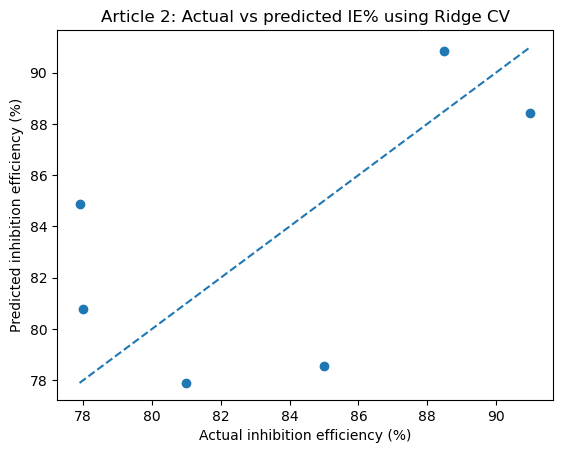

In [27]:
plt.scatter(prediction_comparison["inhibition_efficiency_percent"],
            prediction_comparison["ridge_cv_prediction"])

plt.xlabel("Actual inhibition efficiency (%)")
plt.ylabel("Predicted inhibition efficiency (%)")
plt.title("Article 2: Actual vs predicted IE% using Ridge CV")

min_value = min(prediction_comparison["inhibition_efficiency_percent"].min(),
                prediction_comparison["ridge_cv_prediction"].min())

max_value = max(prediction_comparison["inhibition_efficiency_percent"].max(),
                prediction_comparison["ridge_cv_prediction"].max())

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.show()

## Ridge Regression: actual vs predicted plot

The actual vs predicted plot compares experimental inhibition efficiency with Ridge Regression Leave-One-Out cross-validation predictions.

The dashed diagonal line represents perfect prediction. Points closer to the line indicate better predictions.

The points do not fall perfectly on the diagonal line, showing that the model has limited row-level predictive accuracy.

This limitation is expected because the dataset contains only six rows, and the experimental method was not included as an input feature. Therefore, the Ridge model should be interpreted as an exploratory baseline rather than a reliable predictive model.

## Save modeling findings report

The baseline modeling findings are summarized and saved as a Markdown report in the reports folder.

In [28]:
modeling_findings_file = reports_path / "modeling_findings_project2.md"

modeling_findings_text = """# Modeling Findings — Project 2

## Project title

Descriptor-based baseline modeling of corrosion inhibition efficiency.

---

## 1. Modeling goal

The goal of this modeling step was to build simple exploratory baseline models using descriptor-based features from Article 2.

The target variable was:

`inhibition_efficiency_percent`

The selected input features were:

- temperature_K
- EHOMO_eV
- ELUMO_eV
- energy_gap_eV
- hardness_eV
- fraction_electron_transfer_deltaN
- adsorption_energy_kcal_mol

The goal was not to build a strong predictive model, but to test whether descriptor-based features show an initial signal for explaining inhibition efficiency.

---

## 2. Dataset used

Only the Article 2 clean dataset was used for baseline supervised modeling.

File:

`data/processed/article2_clean_temperature_target_v1.csv`

Dataset size:

- 6 rows
- 7 selected input features
- 1 target variable

The dataset contains three temperatures and two experimental methods:

- Polarization
- EIS

---

## 3. Models tested

Two simple regression models were tested:

1. Linear Regression
2. Ridge Regression

Both models were evaluated using:

- training performance
- Leave-One-Out cross-validation

Leave-One-Out cross-validation was selected because the dataset contains only six rows.

---

## 4. Linear Regression results

### Training performance

- MAE ≈ 2.10
- RMSE ≈ 2.34
- R² ≈ 0.78

### Leave-One-Out cross-validation performance

- MAE ≈ 4.21
- RMSE ≈ 4.68
- R² ≈ 0.13

The Linear Regression model showed much weaker performance under cross-validation than on the training data.

This indicates that the model has limited predictive ability on unseen rows.

---

## 5. Ridge Regression results

### Training performance

- MAE ≈ 2.10
- RMSE ≈ 2.34
- R² ≈ 0.78

### Leave-One-Out cross-validation performance

- MAE ≈ 4.04
- RMSE ≈ 4.47
- R² ≈ 0.21

Ridge Regression slightly improved the cross-validation metrics compared with Linear Regression.

However, the improvement was small and the model is still limited by the very small dataset size.

---

## 6. Model comparison

Ridge Regression showed slightly better Leave-One-Out cross-validation performance than Linear Regression:

- Linear Regression CV R² ≈ 0.13
- Ridge Regression CV R² ≈ 0.21

However, both models should be interpreted as exploratory baselines only.

The dataset is too small to support strong predictive conclusions.

---

## 7. Actual vs predicted interpretation

The actual vs predicted comparison showed that the Ridge model captures part of the temperature-related trend, but the row-level predictions are limited.

One important limitation is that the experimental method was not included as an input feature.

As a result, the model cannot fully distinguish between polarization and EIS rows at the same temperature.

---

## 8. Main modeling conclusion

The descriptor-based features show a limited initial signal for explaining inhibition efficiency.

However, the current dataset is too small for reliable supervised machine learning.

The modeling results should be reported as proof-of-concept baseline modeling, not as a validated predictive model.

---

## 9. Recommended next step

Future modeling should include a larger dataset with more molecules, more experimental conditions, and consistent molecule-level targets.

For the current project, the baseline models are sufficient to demonstrate the workflow:

raw data → clean descriptors → EDA → baseline modeling → scientific interpretation"""

modeling_findings_file.write_text(modeling_findings_text, encoding="utf-8")

print("Modeling findings report saved:")
print(modeling_findings_file)
print("File exists:", modeling_findings_file.exists())

Modeling findings report saved:
D:\AI\ai-corrosion-roadmap\project2_descriptor\reports\modeling_findings_project2.md
File exists: True
